In [1]:
#Lets have matplotlib "inline"
%matplotlib inline

# Add line profiler
%load_ext line_profiler

#Import packages we need
from matplotlib import animation, rc
from matplotlib import pyplot as plt

import importlib

try:
    from StringIO import StringIO
except ImportError:
    from io import StringIO
    
#Set large figure sizes
#Note, this prevents nice figures for articles...
rc('figure', figsize=(16.0, 12.0))
rc('animation', html='html5')

from GPUSimulators.common import common
from GPUSimulators.helpers import InitialConditions

In [2]:
%setup_logging --out=test_schemes.log TestSchemes

Console logger using level INFO
File logger using level DEBUG to test_schemes.log
Python version 3.9.19 | packaged by conda-forge | (main, Mar 20 2024, 12:50:21) 
[GCC 12.3.0]


In [3]:
%cuda_context_handler my_context

Registering my_context in user workspace
PyCUDA version 2024.1
CUDA version (11, 8, 0)
Driver version 12080
Using device 0/1 'NVIDIA GeForce GTX 970' (0000:07:00.0) GPU


Created context handle <98151551869168>
Using CUDA cache dir /home/smyalygames/PycharmProjects/FiniteVolumeGPU/GPUSimulators/cuda_cache
Autotuning enabled. It may take several minutes to run the code the first time: have patience


In [4]:
nx = 256
ny = 128
g = 9.81

h0, hu0, hv0, dx, dy = InitialConditions.bump(nx, ny, 100, 100, 15)

# print(my_context.autotuner.get)

arguments = {
    'context': my_context,
    'h0': h0, 'hu0': hu0, 'hv0': hv0,
    'nx': nx, 'ny': ny,
    'dx': dx, 'dy': dy, 
    'g': g,
    'compile_opts': ['-Wno-deprecated-gpu-targets', '-arch=sm_52']
}

t_end = 20

In [5]:
def plot(sim):
    h = sim.u0[0].download(sim.stream)
    
    plt.figure()
    plt.title(str(sim) + ", t=" + str(sim.sim_time()) + ", nt=" + str(sim.sim_steps()))
    extent = [0, sim.dx*sim.nx, 0, sim.dy*sim.ny]
    plt.imshow(h, vmin=0.49, vmax=0.52, extent=extent)
    plt.colorbar()

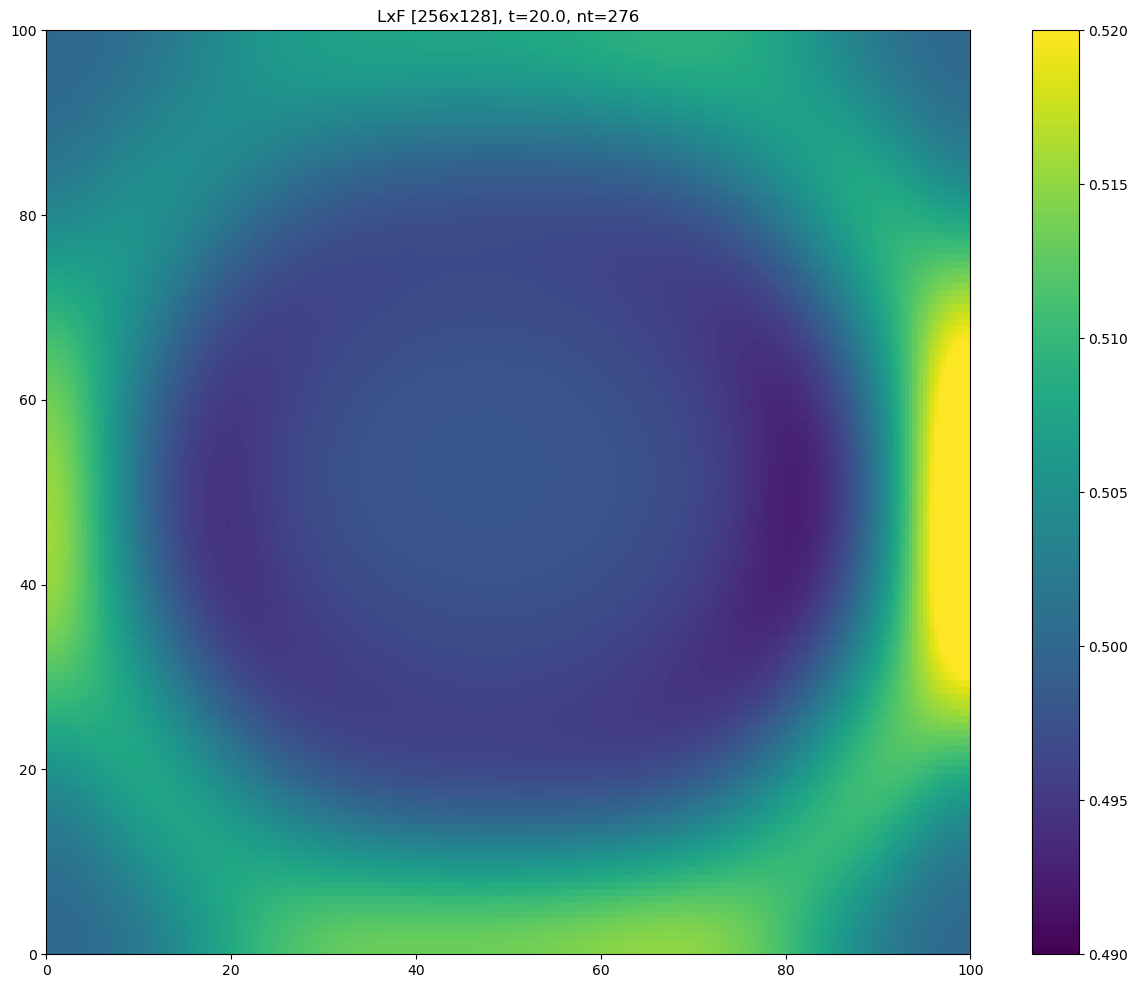

In [6]:
from GPUSimulators import LxF
importlib.reload(LxF)

with Common.Timer("construct") as t:
    sim = LxF.LxF(**arguments)

with Common.Timer("step") as t:
    t = sim.simulate(t_end)
    
with Common.Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

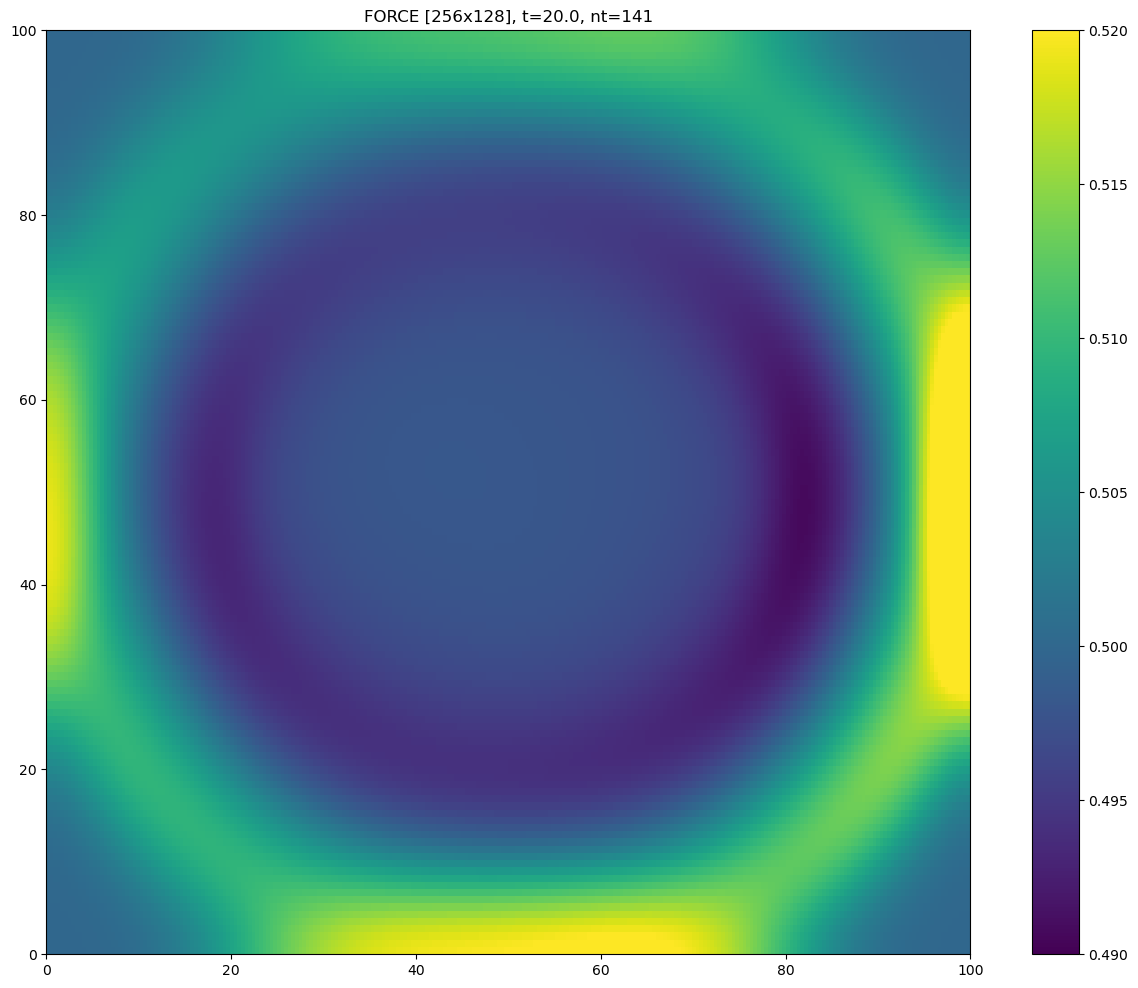

In [7]:
from GPUSimulators import FORCE
importlib.reload(FORCE)

with Common.Timer("construct") as t:
    sim = FORCE.FORCE(**arguments)

with Common.Timer("step") as t:
    t = sim.simulate(t_end)
    
with Common.Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

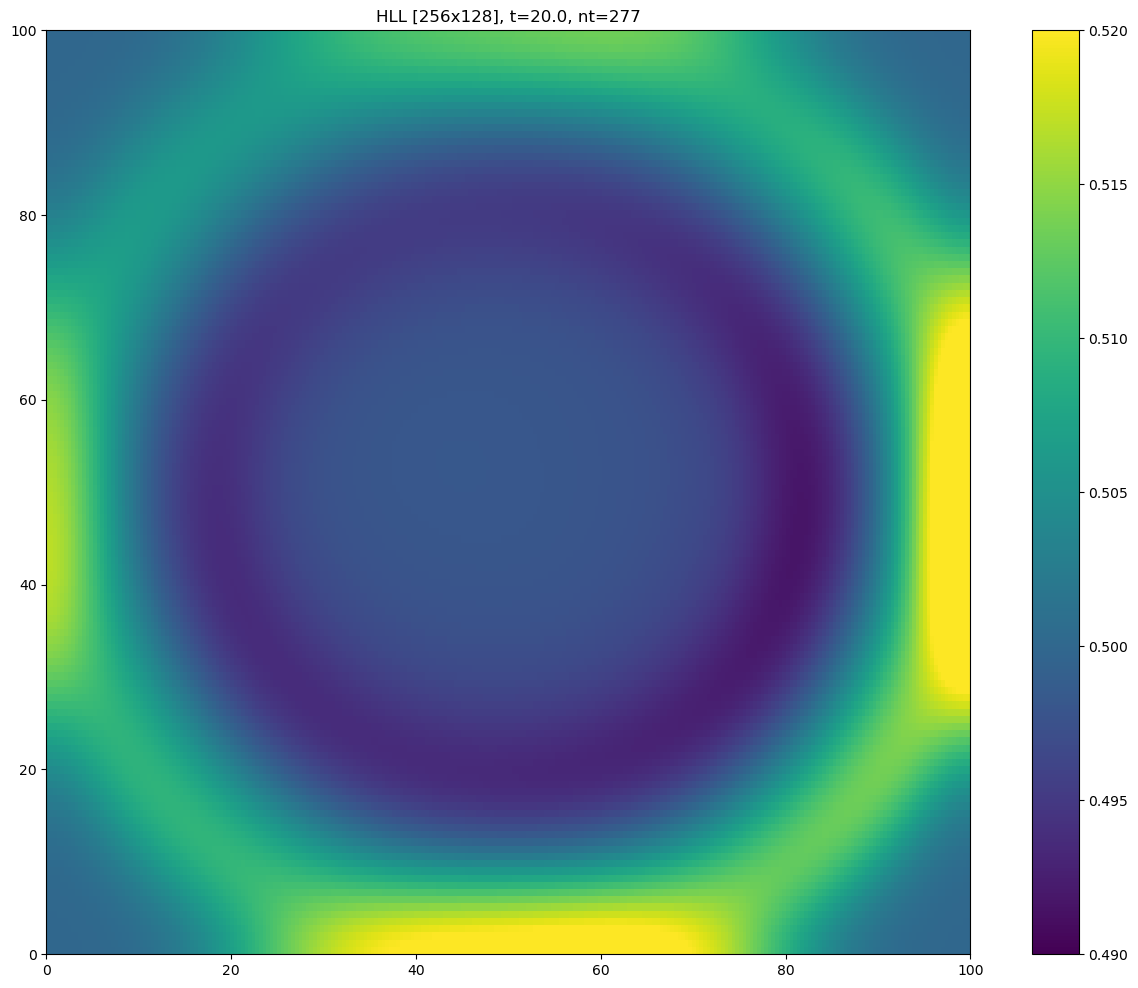

In [8]:
from GPUSimulators import HLL
importlib.reload(HLL)

with Common.Timer("construct") as t:
    sim = HLL.HLL(**arguments)

with Common.Timer("step") as t:
    t = sim.simulate(t_end)
    
with Common.Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

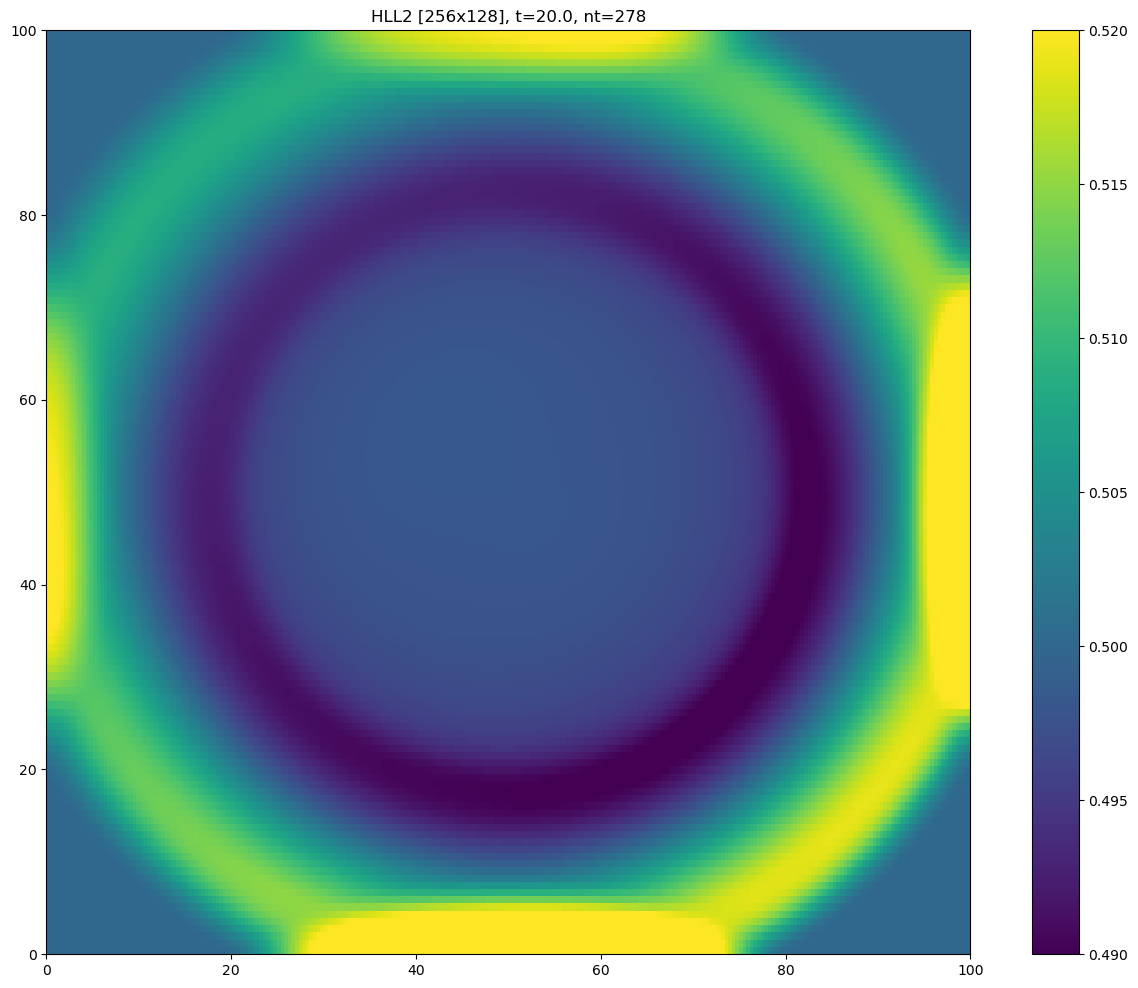

In [9]:
from GPUSimulators import HLL2
importlib.reload(HLL2)

with Common.Timer("construct") as t:
    sim = HLL2.HLL2(**arguments)

with Common.Timer("step") as t:
    t = sim.simulate(t_end)
    
with Common.Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

In [10]:
from GPUSimulators import KP07
importlib.reload(KP07)

with Common.Timer("construct") as t:
    sim = KP07.KP07(**arguments)

with Common.Timer("step") as t:
    t = sim.simulate(t_end)
    
with Common.Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Benchmarking KP07 to autotuning_data_archvm.npz
PyCUDA version 2024.1
CUDA version (11, 8, 0)
Driver version 12080
Using device 0/1 'NVIDIA GeForce GTX 970' (0000:07:00.0) GPU
Created context handle <98151567013168>
Using CUDA cache dir /home/smyalygames/PycharmProjects/FiniteVolumeGPU/GPUSimulators/cuda_cache


KeyboardInterrupt: 

Benchmarking KP07_dimsplit to autotuning_data_archvm.npz
PyCUDA version 2024.1
CUDA version (11, 8, 0)
Driver version 12080
Using device 0/1 'NVIDIA GeForce GTX 970' (0000:07:00.0) GPU
Created context handle <100365813949744>
Using CUDA cache dir /home/smyalygames/PycharmProjects/FiniteVolumeGPU/GPUSimulators/cuda_cache
Cleaning up CUDA context handle <100365813949744>


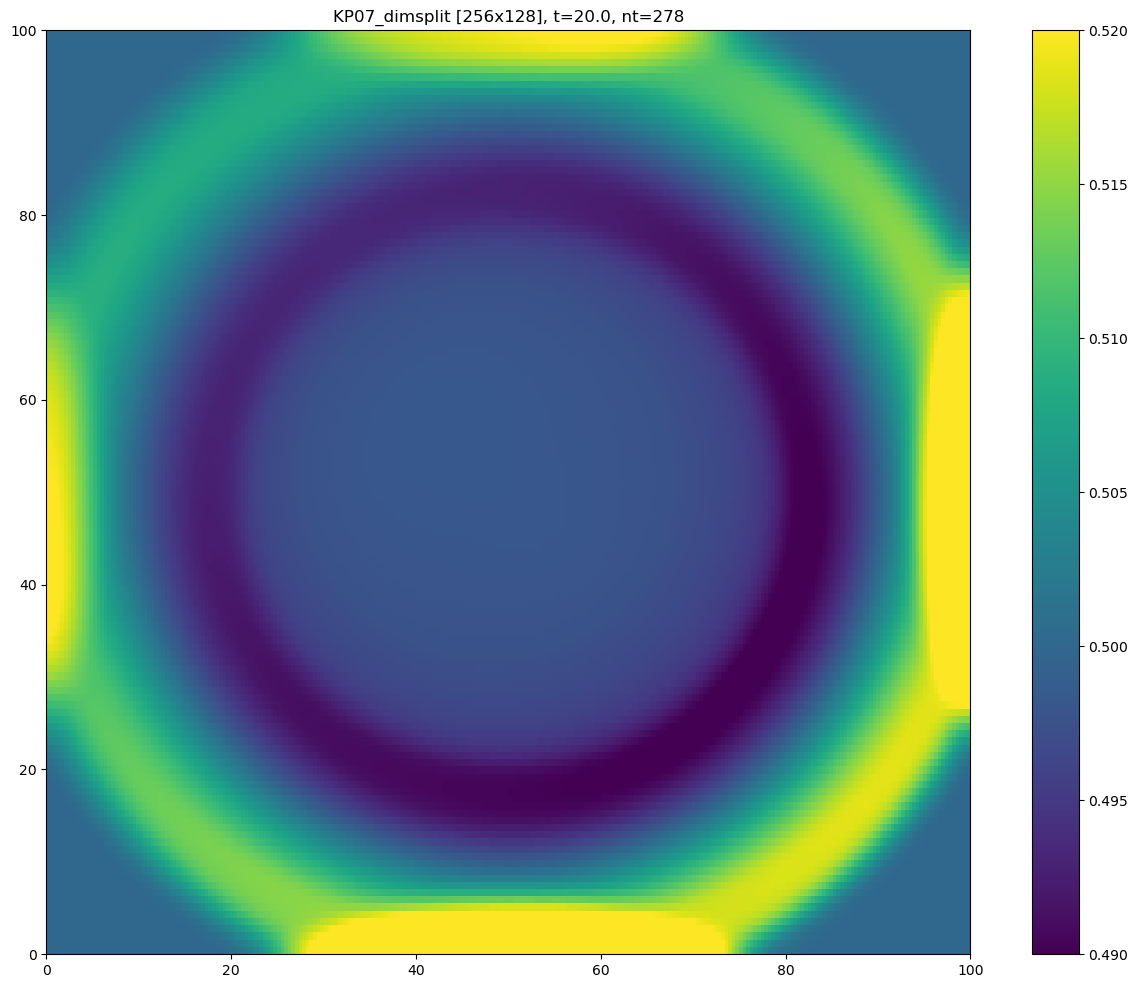

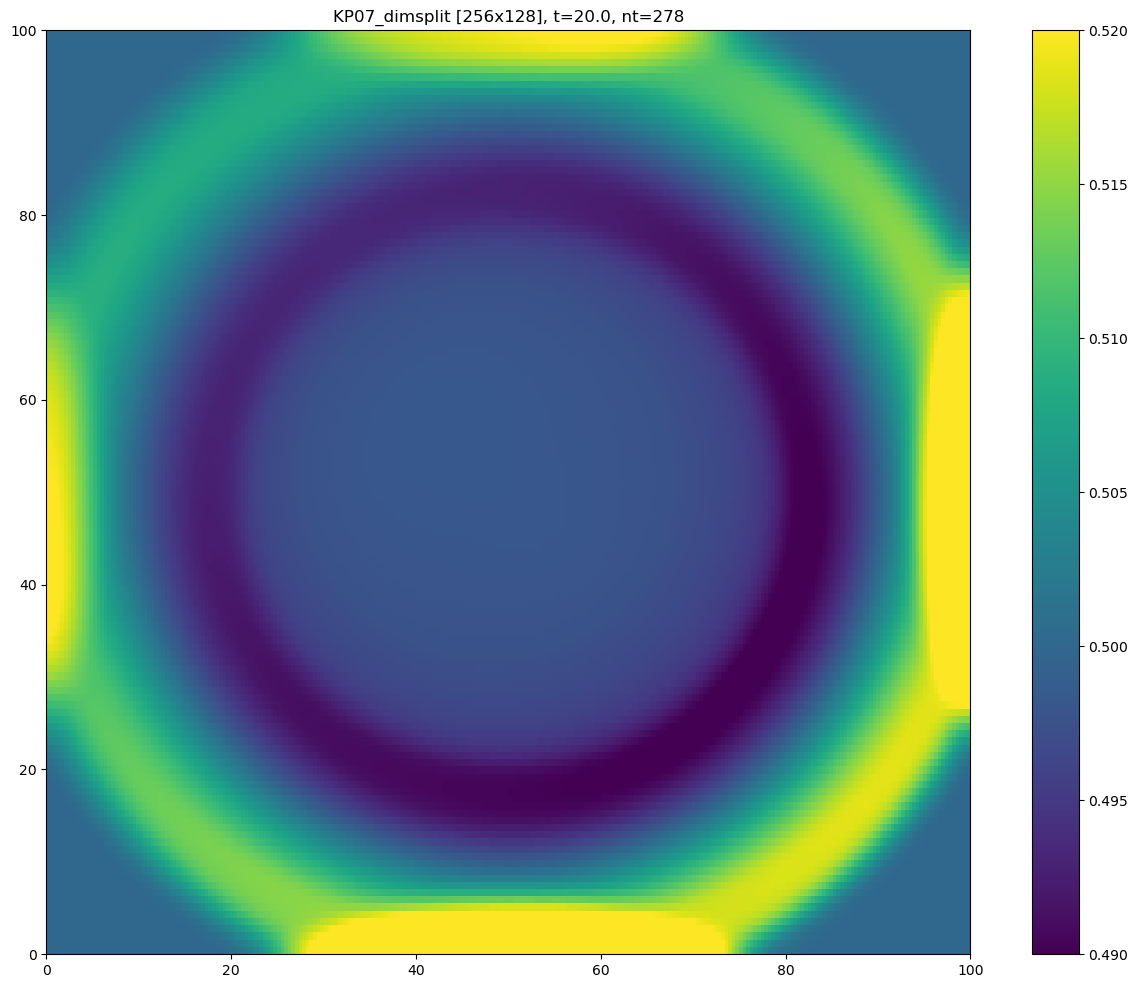

In [ ]:
from GPUSimulators import KP07_dimsplit
importlib.reload(KP07_dimsplit)

with Common.Timer("construct") as t:
    sim = KP07_dimsplit.KP07_dimsplit(**arguments)

with Common.Timer("step") as t:
    t = sim.simulate(t_end)
    
with Common.Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

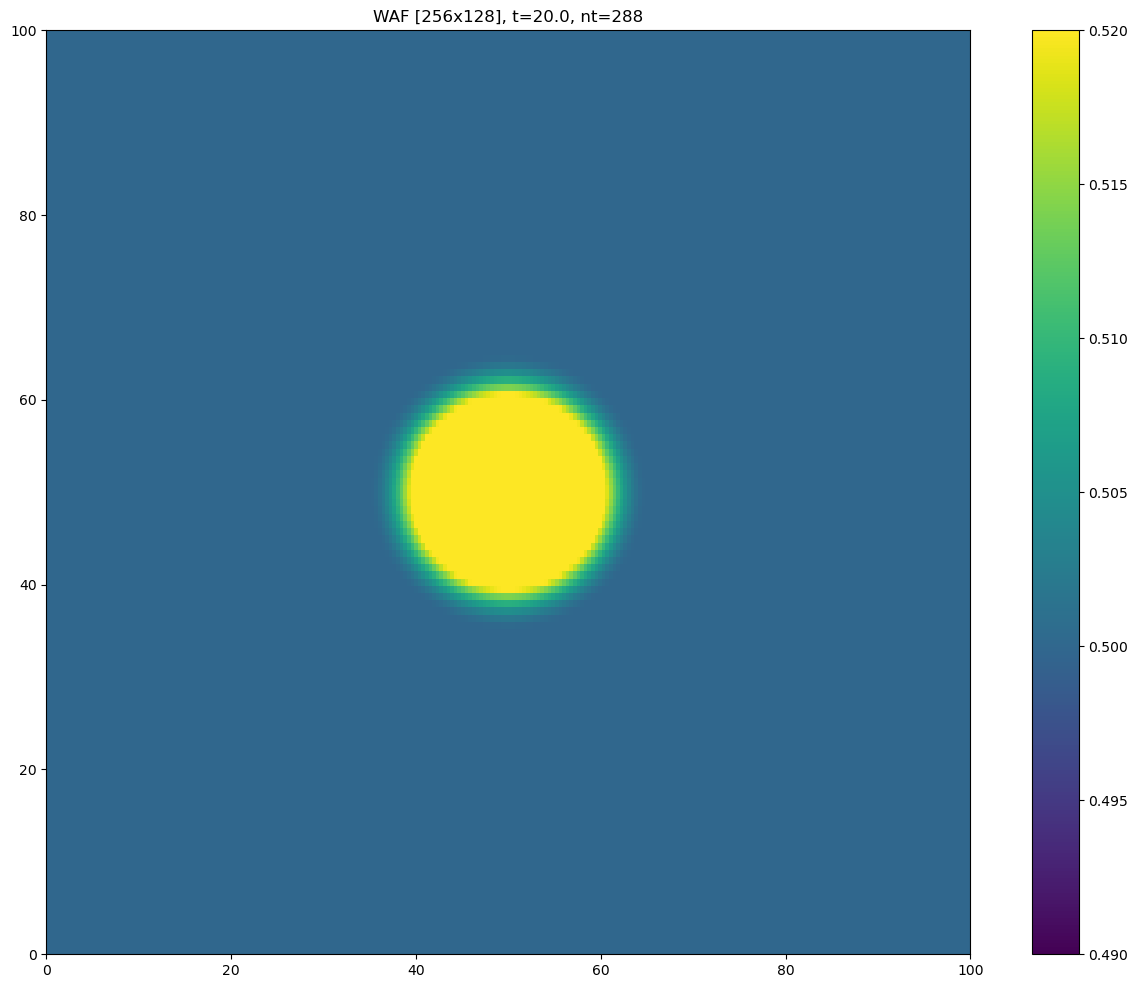

In [13]:
from GPUSimulators import WAF
importlib.reload(WAF)

with Common.Timer("construct") as t:
    sim = WAF.WAF(**arguments)

with Common.Timer("step") as t:
    t = sim.simulate(t_end)
    
with Common.Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)